# La$_{2}$CuO$_{4}$

La$_{2}$CuO$_{4}$ crystallizes in the layered perovskite-derived K$_{2}$NiF$_{4}$ structure, consisting of CuO$_{2}$ planes separated by La-O spacter layers. Each Cu atom sits in an octahedral environment of oxygen atoms, with a nominal Cu$^{2+}$ ($3d^{9}$) configuration. The electronic structure is dominated by strong hybridization between Cu($3d$) and O($2p$) states, placing La$_{2}$CuO$_{4}$ in the charge-transfer insulatore regime of the Zaanen-Sawatzky-Allen classification. Its most famous role is as the parent compound of high-T$_{c}$ cuprate superconductors, becoming a superconductor upon hole or electron doping. Standard DFT predicts a metallic state because it cannot capture the strong local Coulomb replusion and charge-transfer gap that arise from the interplay of copper and oxygen orbitals. DFT+DMFT, particularly in a large energy window including both Cu and O states, is essential to describe the experimentally observed insulating behavior, spectral weight transfer, and the multi-orbtial nature of the correlations.

### 🧪 Exercise 0: Import Modest and Load the DFT data
Load the ``triqs_modest`` module, use the function ``one_body_elements_from_dft_converter`` to load in the HDF5 which was produced by the Wien2k DFT converter in ``la2cuo4/la2cuo4.h5``.

> 💡 **Tip:** The function ``one_body_elements_from_dft_converter`` returns the target density and the one-body elements.

Print both the target electron density and the one_body_elements and pause for a moment to see if this information makes sense for La$_{2}$CuO$_{4}$.

In [1]:
import triqs_modest as modest

target_density, obe = modest.one_body_elements_from_dft_converter("la2cuo4/la2cuo4.h5")
print(f"target_density= {round(target_density)}e- ( 6e- x 4 O + 9e- x 1 Cu = 33e-)\n")
print(obe)

target_density= 33e- ( 6e- x 4 O + 9e- x 1 Cu = 33e-)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 44
      Represented on a fixed grid of 40 points.
      Shape of H[k_idx, σ, ν, ν'] = [40, 1, 44, 44]
      ε^σ(k) is matrix valued? = false
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 5
      Number of correlated atoms: 1
      Number of inequivalent correlated atoms = 1
      Atomic decomposition:
         dim_a:   5
             a:   0
        irreps: [1, 1, 1, 1, 1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [40, 1, 5, 44]
  IBZ = true
    [I]rreduicible [B]rillouin [Z]one symmetry operations from the DFT code [ibz_symmetry_ops]
      Number of symmetry ops: 16
      Number of rotations per op: 1



#### 🔎 Explanation of the OBE

We are studying La$_{2}$CuO$_{4}$ within a large-energy window which fully includes the hybridizaition between the O($2p$) and Cu($3d$) states. The ``OneBodyElementsOnGrid`` is composed of four pieces that represent the one-body physics that is obtained from DFT and will be used in the DMFT calculation.

The one-body elements (OBE) class contains four pieces:

##### 🔹 H: Band dispersion $\varepsilon^{\sigma}(k)$
This is the DFT Kohn-Sham eigenvalues: $\varepsilon^{\sigma}(k)$ is the **band energy** for spin ($\sigma$) at $k$.

##### 🔹 C_space: Local (correlated) orbital space
This describes the **correlated subspace** $\mathcal{C}$ -- the one that will be used in the DMFT impurity model. We created a projector for all five Cu($3d$) orbitals and we indicated we wanted to treat this atom as correlated. This following is reflected in the print out: (1) correlated atom with orbital dimension 5

##### 🔹 P: Downfolding projector
This is the projector that we introduced in [Tutorial 05](05s-dftdmft.ipynb). Importantly, we print the shape of the projector so that the user can confirm that this is what they expect.

##### 🔹 IBZ: Irreducible Brillouin zone Ops
Some DFT codes perform the summation in the Brillouin zone within the irreducible Brillouin zone. For those cases, to obtain obversables like the local Green's function, we must symmetrize those quantities. The IBZ operations are internally read and stored. We apply them whenever appropriate. In practice, there's no need to worry about them 🙂. The 16 symmetry operations correspond to the $I4/mmm$ space group. 

## ⚛️ The role of covalency in the metal-insulator transition of La$_{2}$CuO$_{4}$
Our goal is to study La$_{2}$CuO$_{4}$ within DFT+DMFT, where we treat only the Cu-$d_{x^{2}-y^{2}}$ as our quantum impurity which we solve within DMFT. All other states will be treated at the Hartree level within DFT. While we will not study the effects of charge self-consistency, the script that you will develop in the notebook can easily be adapted to perform charge self-consistent calculations. At the end of the notebook, we will describe how this is done.

Within the DFT + DMFT theory, the so-called "double-counting" term plays a critical role in achieving the correct physics. [Wang et. al.](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.86.195136) calculated the metal-insulator phase diagram for La$_{2}$CuO$_{4}$ in the plane of Hubbard interaction and $N_{d}$ where $N_{d}$ is the total filling of the Cu-$_{x^{2}-y^{2}}$ orbitals. We will develop a script using TRIQS/ModEST to reproduce the results in Figure 4 (top panel) of their manuscript which correctly captures the insulating behavior of La$_{2}$CuO$_{4}$ but requires an adjustment to the double counting term.

### 🧪 Exercise 1: Create an Embedding Description
Create an embedding from the local space in one-body elements and print it out to the screen.

In [2]:
E = modest.make_embedding(obe.C_space)
print(E)

Embedding: 1 impurities
  Σ_embed block decomposition:
    dim_α:   1   1   1   1   1
        α:   0   1   2   3   4

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1   1   1   1   1
                      γ =   0   1   2   3   4



Up until now we've only seen rather simple embeddings. However, to see the full information contained within the embedding class, use the ``description`` method to get a full print out.

In [3]:
print(E.description(True))

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1   1   1   1
        α:   0   1   2   3   4

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1   1   1   1   1
                      γ =   0   1   2   3   4
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], up_1 [1], up_2 [1], up_3 [1], up_4 [1], down_0 [1], down_1 [1], down_2 [1], down_3 [1], down_4 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  
      α = 1  |   (imp_idx = 0, γ = 1, τ = 0)    (imp_idx = 0, γ = 1, τ = 1)  
      α = 2  |   (imp_idx = 0, γ = 2, τ = 0)    (imp_idx = 0, γ = 2, τ = 1)  
      α = 3  |   (imp_idx = 0, γ = 3, τ = 0)    (imp_idx = 0, γ = 3, τ = 1)  
      α = 4  |   (imp_

In DMFT, the **embedding** tells you how the _correlated subspace_ (from the DFT/Wannier model) is mapped to one or more **impurity problems**. Thus, it is essential to be able to flexibly construct impurity model(s) for your correlated subspace and ensure the correct assignment of local orbitals and spin channesls. Below is a detailed breakdown of the printout from the ``Embedding`` object.

##### 🔹 spin index ($\sigma/\tau$) names: ["up", "down"]
These are the names of the block-diagonal spin indices $\sigma$ used in the impurity model. They correspond to the spin-up and spin-down electrons and will be used to construct the fermionic creation and annihilation operators for the impurity model.

We distinguish between:

- $\sigma$: the spin index in the **embedded problem**, and
- $\tau$: the internal spin index used by the **impurity solver** (e.g., in the impurity solver Green's function blocks).

This distinction allows us to support more generic embeddings.

##### 🔹  $\Sigma$_embed block decomposition
This section describes the **block structure** of the embedded self-energy $\Sigma_{\text{embed}}^{\sigma}(\omega)$. In our case, there are 5 orbitals each represeenting a $1\times1$ block in the self-energy (see $\alpha$ and dim_$\alpha$).

##### 🔹  Impurities
This describes the structure of the **impurity problems** constructed from the local space:

- ``n_imp = 0``: There is one impurity solver (index 0).
- For this impurity solver: there are 5 correlated orbitals with dimension 1 (``dim_γ``).
- The impurity Green's function will therefore have **10 blocks**: 5 for spin-up and 5 for spin-down.

The solver's block structure (``gf_struct``) is printed:
```
[imp_idx = 0] up_0 [1], up_1 [1], up_2 [1], up_3 [1], up_4 [1], down_0 [1], down_1 [1], down_2 [1], down_3 [1], down_4 [1]
```
This means:
- The impurity solver has **10 blocks**, 5 for each spin, and
- Each block is of dimension 1.

##### 🔹 Mapping ψ(α,σ) = (imp_idx, γ, τ) 
This table gives the **mappping from the embedded indices** ``(α,σ)`` to the **impurity solver indices** ``(imp_idx, γ, τ)``.

For this case, the mapping is simple the five blocks of the impurity self-energy are directly mapped to the five blocks in the embedded self-energy. For trivial cases like this, the printing of the embedding is greatly simplified.

### 🧪 Exercise 2: From 5 correlated orbtials to 1 correlated orbital

We constructed a five-orbital correlated subspace for the Cu($3d$) orbitals, which is currently treated as a single correlated impurity. However, one could instread split off certain orbitals to treat them with a different impurity solver or exclude them from the impurity altogether. For example, in Cu$^{2+}$ ($3d^{9}$), the $t_{2g}$ shell is fully filled, so--at least to first approximation -- correlation effects in this sector are expected to be weak. Furthermore, due to the large octahedral elongation, the $e_{g}$ levels are strongly split, with the $3z^{2}-r^{2}$ orbital lying lower in energy and filling first, leaving the $d_{x^{2}-y^{2}}$ orbital approximately half-filled and at the Fermi level. 

In this exercise, let's modify embedding to reflect that we want to solve a single impurity problem for the Cu $d_{x^{2}-y^{2}}$ orbital removing the other four orbitals from the impurity. To achieve this, we will use the ``split`` and ``drop`` methods of the Embedding class. Of course, you also need to know the orbital order. The orbital order is dependent on the DFT code you are using and the different DFT codes order the $3d$ orbitals differently. For Wien2k, the orbital order is: $d_{3z^{2}-r^{2}}$, $d_{x^{2}-y^{2}}$, $d_{xy}$, $d_{xz}$, and $d_{yz}$.

> The **E.split** function takes two arguments: an impurity index and a list of blocks.
> 
> The **E.drop** function takes the index of an impurity solver to drop from the list. Dropping an impurity solver means that you want to replace the self-energy that it connects to with a zero self-energy.
>
> 💡 **Tip:** Each method returns a new embedding, so you do not have to worry about accidently making changes to the underlying embedding ``E`` that we are working with.

#### 🧩 Your Task
1. Use the split method to divide the Embedding into two impurity solvers: 1 for the Cu-$d_{x^{2}-y^{2}}$ and 1 for the remaining 4 orbitals.
```python
E1 = E.split(0, """your answer""")
```
2. Use the drop method to drop the impurity solver that we do not want to keep.
```python
E1.drop("""your answer""")
```
3. String the two operations together.
```python
E2 = E.split(""" """).drop(""" """)
```

In [4]:
print(E.split(0, [1]).drop(1).description(True))

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1   1   1   1
        α:   0   1   2   3   4

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], down_0 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |           σ = 0 / up                     σ = 1 / down           
      -------+--------------------------------+-------------------------------+
      α = 1  |    (imp_idx = 0, γ = 0, τ = 0)     (imp_idx = 0, γ = 0, τ = 1)  



## 🧠 DMFT loop

### 🧪 Exercise 3: Write the DMFT loop

In the DMFT loop, can be written almost identically to the one that you worked on in the previous tutorials. You will make a slight modification to the static part of the self-energy to incorporate the double-counting.

In [5]:
import numpy as np
from triqs.gf import MeshImFreq
from triqs.operators import n
from utils.solvers import solve

# Coulomb interaction
U = 14    

# double-counting density
N_d = 1.1 

# Matsubara Mesh
mesh = MeshImFreq(beta = 10.0, S = "Fermion", n_iw = 250)

# load in density and obe
target_density, obe = modest.one_body_elements_from_dft_converter("la2cuo4/la2cuo4.h5")

# create embedding
E = modest.make_embedding(obe.C_space).split(0, [1]).drop(1)

# setup-solver parameters (realistic solver parameters: length_cycle = 9000, n_cycles = 9e+6, n_warmup_cycles = 1e+4)
solver_params = dict(length_cycle=100, n_cycles = int(1e+5),
                     n_warmup_cycles = int(1e+3), 
                     perform_tail_fit=True, fit_min_w=24,
                     fit_max_w=28, imag_threshold = 1e-6)

# make an empty self-energy
Sigma_imp_dynamic, Sigma_imp_static = E.make_zero_imp_self_energies(mesh)[0]

# compute the double-counting and set it equal to the static part of the self-energy
Sigma_DC = U*(N_d - 0.5)

for SH in Sigma_imp_static: SH += Sigma_DC*np.eye(SH.shape[0])

# interaction Hamiltonian
h_int = U*n('up_0',0)*n('down_0',0)

# number of DMFT iterations
n_dmft_loops = 2

epsilon_d = E.extract(modest.impurity_levels(obe))[0]

for n_iter in range(n_dmft_loops):

    # embed the impurity self-energy
    Sigma_C_dynamic, Sigma_C_static = E.embed([Sigma_imp_dynamic], [Sigma_imp_static])

    # find the chemical potential
    mu = modest.find_chemical_potential(target_density, obe, Sigma_C_dynamic, Sigma_C_static, verbosity=False)

    # compute the local Green's function
    Gloc = E.extract(modest.gloc(obe, mu, Sigma_C_dynamic, Sigma_C_static))[0]

    # Compute the effective impurity levels
    hloc0 = [ block - mu*np.eye(block.shape[0]) for block in epsilon_d]

    # Compute hybridization function
    Delta_iw = modest.hybridization(hloc0, Gloc, Sigma_imp_dynamic, Sigma_imp_static)

    # solve the quantum impurity problem
    solver_results = solve(Delta_iw, hloc0, h_int, **solver_params)

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")

    # update the impurity self-energy
    Sigma_imp_dynamic, Sigma_imp_static = solver_results.Sigma_dynamic, solver_results.Sigma_Hartree

    # subtract double counting from the static part of the self-energy
    for SH in Sigma_imp_static: SH -= Sigma_DC*np.eye(SH.shape[0])

Starting serial run at: 2025-08-10 15:52:51.392117


Δn = |n_lattice - n_impurity| = 0.878521512701619

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-4.53577*c_dag('down_0',0)*c('down_0',0) + -4.53577*c_dag('up_0',0)*c('up_0',0) + 14*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
15:52:52 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
15:52:52   2% ETA 00:00:04 cycle 2093 of 100000
15:52:55  43% ETA 00:00:02 cycle 43688 of 100000
15:52:57  95% ETA 00:00:00 cycle 95671 of 100000
15:52:57 100% ETA 00:00:00 cycle 99999 of 100000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure                                    | seconds   
Auto-correlation time                      | 0.00702468
Average order                              | 0.00145142
Average sign          

Execution time: 0.0675037 seconds
Execution time: 0.0684083 seconds


## 📊 Analyze Results

### 🧪 Exercise 4: Load in converged results

Now that you have your DMFT loop, we provide you with pre-converged results for this calculation at $\beta = 50.0$ 1/eV. Load in the converged data from the file ``lco-x2y2-Nd=1.1-beta=50.0-U=14.0.h5``. Plot the self-energy and Green's function from the first and last iteration and write a few comments.

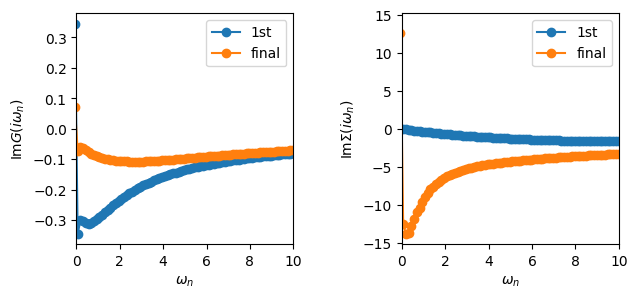

In [33]:
from h5 import HDFArchive

with HDFArchive('la2cuo4/lco-x2y2-Nd=1.1-beta=50.0-U=14.0.h5', 'r') as ar:
    last_iter = str(len(ar)-1)
    Sigma_iw_first = ar['0']['Sigma_imp_list'][0]
    Sigma_iw_last  = ar[last_iter]['Sigma_imp_list'][0]

    G_iw_first = ar['0']['Gimp_freq_list'][0]
    G_iw_last  = ar[last_iter]['Gimp_freq_list'][0]

    mu_last = ar[last_iter]['mu']
    
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(G_iw_first['up_0'].imag, 'o-', label='1st'); 
ax[0].oplot(G_iw_last['up_0'].imag, 'o-', label='final'); ax[0].set_ylabel(r'Im$G(i\omega_{n})$')
ax[1].oplot(Sigma_iw_first['up_0'].imag, 'o-', label='1st'); 
ax[1].oplot(Sigma_iw_last['up_0'].imag, 'o-', label='final'); ax[1].set_ylabel(r'Im$\Sigma(i\omega_{n})$')
ax[0].legend(); ax[0].set_xlim(0, 10)
plt.subplots_adjust(wspace=0.5)
plt.show()

At the first iteration, both the Green's function and self-energy indicate metallic behavior. However, at convergence, they both show insulating behavior.

### 🧪 Exercise 5: Analytically continue the self-energy
Now let's analytically contine the self-energy onto the real-axis so that we can plot real-frequency spectra. Use the maximum entropy utilities from before to analytically continue the self-energy from the last iteration. Plot your result.

In [84]:
from utils.maxent import Sigma_w_from_maxent

Sigma_w = Sigma_w_from_maxent(Sigma_iw_last, alpha_min=1e-2, alpha_max=1e2, error=0.04)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-08-10 16:43:07.651954
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.004351591662971362
scaling alpha by a factor 6151 (number of data points)
alpha[ 0] =   6.15100000e+05, chi2 =   2.01199773e+03, n_iter=       4 
alpha[ 1] =   5.09698170e+05, chi2 =   2.00508285e+03, n_iter=       3 
alpha[ 2] =   4.22357705e+05, chi2 =   1.99682641e+03, n_iter=       3 
alpha[ 3] =   3.49983659e+05, chi2 =   1.98698876e+03, n_iter=       3 
alpha[ 4] =   2.90011430e+05, chi2 =   1.97529619e+03, n_iter=       3 
alpha[ 5] =   2.40315876e+05, chi2 =   1.96143969e+03, n_iter=       3 


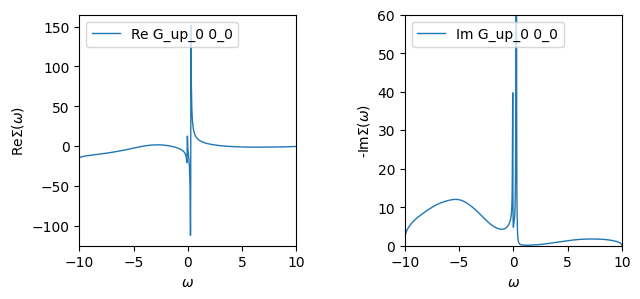

In [85]:
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(Sigma_w['up_0'] -Sigma_w['up_0'][0,0](0.0).real, mode='R', lw=1)
ax[1].oplot(-Sigma_w['up_0'].imag, lw=1)
ax[0].legend(loc='upper left'); ax[1].legend(loc='upper left')
ax[0].set_xlim(-10,10); ax[1].set_ylim(0, 60); 
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 6: Compute real-frequency spectra
Now we will learn how to plot the atom- and orbital-resolved spectral function -- the interacting density of states. The quantity that we wan to compute is

$$ A_{\mathrm{proj}}(\omega) = \frac{-1}{\pi} \mathrm{Im} G_{\mathrm{proj}}(\omega), $$

where $G_{\mathrm{proj}}$ is the local Green's function projected onto atom $a$ and orbital $o$.

In [81]:
obe_proj = modest.one_body_elements_with_theta_projectors('la2cuo4/la2cuo4.h5', obe)
print(obe_proj)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 44
      Represented on a fixed grid of 40 points.
      Shape of H[k_idx, σ, ν, ν'] = [40, 1, 44, 44]
      ε^σ(k) is matrix valued? = false
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 27
      Number of correlated atoms: 7
      Number of inequivalent correlated atoms = 4
      Atomic decomposition:
         dim_a:   5   5   5   3   3   3   3
             a:   0   1   2   3   4   5   6
        irreps: [5] [5] [1, 1, 1, 1, 1] [3] [3] [3] [3]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [40, 1, 27, 44]
  IBZ = true
    [I]rreduicible [B]rillouin [Z]one symmetry operations from the DFT code [ibz_symmetry_ops]
      Number of symmetry ops: 16
      Number of rotations per op: 

In [86]:
Sigma_w_proj = E.embed([Sigma_w - Sigma_DC])
A_proj = modest.projected_spectral_function(obe_theta, obe.P, mu_last, Sigma_w_proj, broadening=0.05)

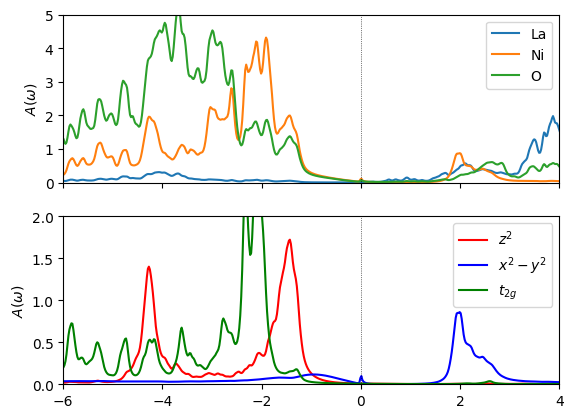

In [90]:
La = A_proj.per_theta[0,:,:10, :10].trace(axis1=1,axis2=2)
Ni = A_proj.per_theta[0,:,10:15,10:15].trace(axis1=1,axis2=2)
O  = A_proj.per_theta[0,:,16:, 16:].trace(axis1=1,axis2=2)

mesh = np.fromiter(Sigma_w_proj['0','up'].mesh, float)

fig, ax = plt.subplots(2,1,sharex=True)
ax[0].plot(mesh, 2*La.real, label="La")
ax[0].plot(mesh, 2*Ni.real, label="Ni")
ax[0].plot(mesh, 2*O.real, label="O")
ax[0].set_ylim(0,5); ax[0].legend(); ax[0].axvline(0.0, color='k', ls='dotted', lw=0.5); ax[0].set_ylabel(r'$A(\omega)$')

ax[1].plot(mesh, 2*A_proj.per_theta[0,:,10,10].real, color='red', label=r'$z^{2}$')
ax[1].plot(mesh, 2*A_proj.per_theta[0,:,11,11].real, color='blue', label=r'$x^{2}-y^{2}$')
ax[1].plot(mesh, 3*A_proj.per_theta[0,:,12,12].real, color='green', label=r'$t_{2g}$')
ax[1].set_ylim(0,2); ax[1].legend(); ax[1].axvline(0.0, color='k', ls='dotted', lw=0.5); ax[1].set_ylabel(r'$A(\omega)$')
ax[1].set_xlim(-6, 4)
plt.show()